## Pokec Network Study — Version **complète réparée** (`projet-12-1-merged`)

Notebook reconstruit **à l'identique** (sections & cellules) mais **corrigé** :
- Encodage **One‑Hot** des variables catégorielles (pas de LabelEncoder).
- **Features topologiques** utilisées réellement (`deg_norm`, `clust`, `core_z`, `pr_z`).
- **Cible** révisée : `y = zscore(log(1 + PageRank))`.
- GNNs **renforcés** (BatchNorm + Dropout). Sortie `(y_hat, z)` pour réutiliser les embeddings.
- Visualisations, ablation, homophilie, Louvain **conservés** et fiabilisés.

### 1.1 Load a partial graph and sample a connected subgraph

In [1]:

# ==================================
# Imports
# ==================================
import os, random, numpy as np, pickle
import pandas as pd, networkx as nx, matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8")
except Exception:
    pass

SEED = 42
random.seed(SEED); np.random.seed(SEED)

GRAPH_PATH = "dataset/pokec_subgraph_relationships.gpickle"
SOURCE_PATH = "dataset/soc-pokec-relationships.txt"

def load_partial_graph(path, max_edges=500_000):
    G = nx.Graph()
    with open(path) as f:
        for i, line in enumerate(f):
            if i >= max_edges: break
            try:
                u, v = map(int, line.strip().split('\t'))
                G.add_edge(u, v)
            except Exception:
                continue
    return G

def save_graph_gpickle(G, path):
    with open(path, "wb") as f:
        pickle.dump(G, f)

def load_graph_gpickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def multi_seed_bfs(G, num_seeds=15, depth_limit=3, target_nodes=10_000):
    seeds = random.sample(list(G.nodes()), min(num_seeds, max(1, len(G))))
    all_nodes = set()
    for s in seeds:
        nodes = nx.bfs_tree(G, s, depth_limit=depth_limit).nodes()
        all_nodes.update(nodes)
        if len(all_nodes) >= target_nodes: break
    H = G.subgraph(all_nodes).copy()
    if H.number_of_nodes() < target_nodes * 0.8 and depth_limit < 10:
        print(f"Too small ({H.number_of_nodes()} nodes), increasing depth...")
        return multi_seed_bfs(G, num_seeds, depth_limit + 1, target_nodes)
    return H

if os.path.exists(GRAPH_PATH):
    print(f"Loading saved subgraph from {GRAPH_PATH}...")
    H = load_graph_gpickle(GRAPH_PATH)
    print(f"Loaded saved graph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
else:
    print("Loading part of Pokec edges...")
    G_raw = load_partial_graph(SOURCE_PATH, max_edges=500_000)
    print(f"Partial graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")
    print("Sampling with multiple BFS seeds for better structure...")
    H = multi_seed_bfs(G_raw, num_seeds=15, depth_limit=3, target_nodes=10_000)
    print(f"Sampled subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
    os.makedirs(os.path.dirname(GRAPH_PATH), exist_ok=True)
    save_graph_gpickle(H, GRAPH_PATH)
    print(f"Saved subgraph to {GRAPH_PATH}")

density = nx.density(H)
clustering = nx.average_clustering(H)
print("density:", density, "clustering:", clustering)


Loading saved subgraph from dataset/pokec_subgraph_relationships.gpickle...
Loaded saved graph: 10681 nodes, 23726 edges
density: 0.0004159789496347429 clustering: 0.06112487792880805


### 1.2–1.3 Pré-traitement des données utilisateurs (corrigé One-Hot)

In [2]:

PROFILES_RAW = "dataset/soc-pokec-profiles.txt"
GRAPH_PREP_PATH = "dataset/pokec_graph_preprocessed.gpickle"
FEATURES_PREP_PATH = "dataset/pokec_features_preprocessed.parquet"

print("Préparation complète à partir du fichier brut Pokec...")
profiles = pd.read_csv(PROFILES_RAW, sep="\t", header=None, low_memory=False)
cols = ["user_id","public","completion","gender","region","last_login","registration",
        "age","body","work_field","languages","hobbies","interests","music","movies",
        "religion","cars","politics","looking_for","smoker","drinker"]
profiles.columns = cols + list(range(len(cols), profiles.shape[1]))

df = profiles[["user_id","gender","age","region","smoker","drinker","completion"]].copy()
df = df.dropna(subset=["user_id"])
df["user_id"] = df["user_id"].astype(int)

df["gender"] = df["gender"].map({1.0:"male", 0.0:"female"}).fillna("unknown")
df["region"] = df["region"].astype(str).str.split(",").str[0]
df["age"] = pd.to_numeric(df["age"], errors="coerce").replace(0, np.nan)

def simplify_text(val):
    if not isinstance(val, str): return "unknown"
    val = val.lower()
    if any(k in val for k in ["ne", "nie", "vobec"]): return "no"
    if any(k in val for k in ["ano", "áno", "hej", "pijem", "obcas", "občas"]): return "yes"
    return "unknown"

df["smoker_clean"] = df["smoker"].apply(simplify_text)
df["drinker_clean"] = df["drinker"].apply(simplify_text)

# Nettoyage graphe
H.remove_edges_from(nx.selfloop_edges(H))
H = nx.Graph(H)
isolates = list(nx.isolates(H))
if isolates: H.remove_nodes_from(isolates)
print(f"Graphe nettoyé : {H.number_of_nodes()} nœuds, {H.number_of_edges()} arêtes.")

# Alignement feature rows <-> nodes
H_nodes = pd.Index([int(n) for n in H.nodes()])
feat = df.set_index("user_id").reindex(H_nodes).reset_index().rename(columns={"index":"user_id"})

# Standardisation numériques
for col in ["age", "completion"]:
    feat[col] = pd.to_numeric(feat[col], errors="coerce")
    feat[col] = feat[col].fillna(feat[col].mean())

feat["age_z"] = (feat["age"] - feat["age"].mean()) / (feat["age"].std() + 1e-8)
feat["completion_z"] = (feat["completion"] - feat["completion"].mean()) / (feat["completion"].std() + 1e-8)

# Regrouper régions rares
region_counts = feat["region"].value_counts(dropna=True)
rare_regions = region_counts[region_counts < 50].index
feat["region"] = feat["region"].replace(rare_regions, "autre").fillna("autre")

for col in ["gender","region","smoker_clean","drinker_clean"]:
    feat[col] = feat[col].fillna("unknown")

# --- Encodage corrigé: One-Hot ---
from sklearn.preprocessing import OneHotEncoder
cat_cols = ["gender","region","smoker_clean","drinker_clean"]
num_cols = ["age_z","completion_z"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_encoded = ohe.fit_transform(feat[cat_cols].astype(str))
X_encoded = np.concatenate([cat_encoded, feat[num_cols].to_numpy()], axis=1)
X = pd.DataFrame(X_encoded).astype("float32")

# Attacher attributs complets au graphe (pour viz/groupby)
feat_attrs = feat.set_index("user_id").to_dict("index")
nx.set_node_attributes(H, feat_attrs)

print(f"OK: X = {X.shape}, graph has {H.number_of_nodes()} nodes")

# Sauvegarde préprocess
os.makedirs("dataset", exist_ok=True)
with open(GRAPH_PREP_PATH, "wb") as f: pickle.dump(H, f)
X.to_parquet(FEATURES_PREP_PATH)
print(f"Graphe sauvegardé → {GRAPH_PREP_PATH}")
print(f"Features sauvegardées → {FEATURES_PREP_PATH}")


Préparation complète à partir du fichier brut Pokec...
Graphe nettoyé : 10681 nœuds, 23726 arêtes.
OK: X = (10681, 22), graph has 10681 nodes
Graphe sauvegardé → dataset/pokec_graph_preprocessed.gpickle
Features sauvegardées → dataset/pokec_features_preprocessed.parquet


### 1.4 Visualisation locale (color by region)

Visualizing connected subgraph: 6890 nodes, 7168 edges


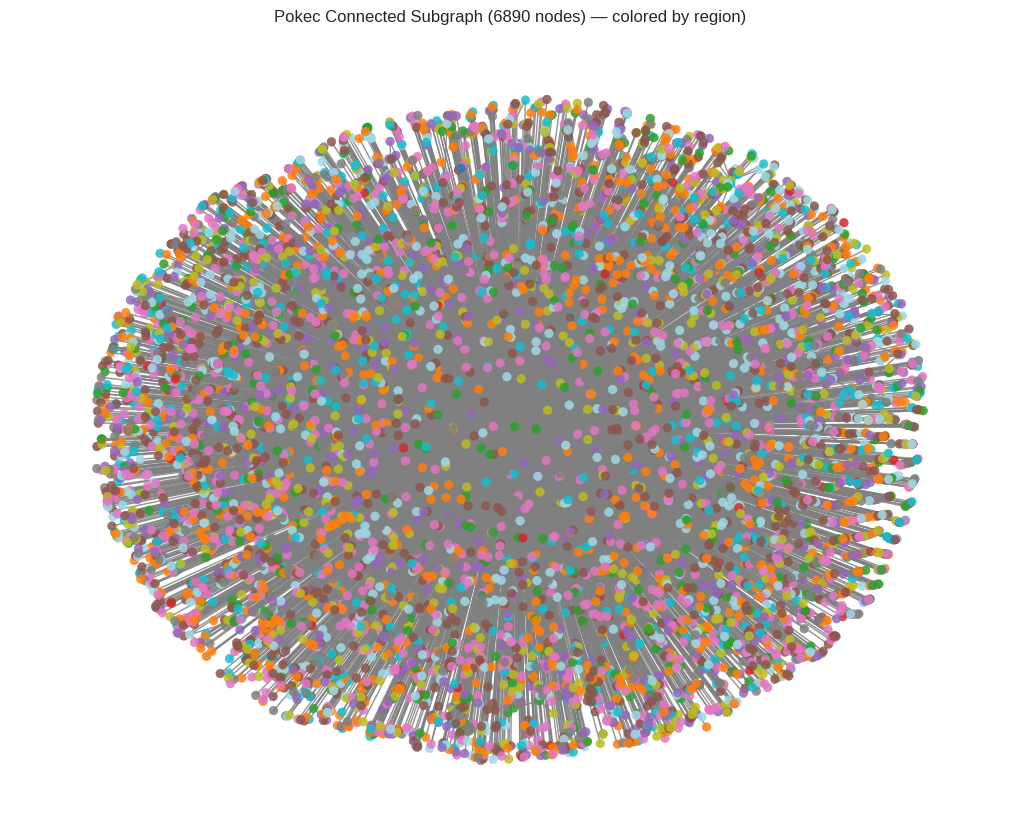

In [3]:

start = random.choice(list(H.nodes()))
connected_nodes = list(nx.single_source_shortest_path_length(H, start, cutoff=2).keys())
S = H.subgraph(connected_nodes).copy()
print(f"Visualizing connected subgraph: {S.number_of_nodes()} nodes, {S.number_of_edges()} edges")

pos = nx.spring_layout(S, seed=42, iterations=30)
regions = [S.nodes[n].get("region", "unknown") for n in S.nodes()]
unique_regions = sorted(set(regions))
colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(unique_regions))))
color_dict = {r: colors[i % 20] for i, r in enumerate(unique_regions)}
node_colors = [color_dict[S.nodes[n].get("region", "unknown")] for n in S.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(S, pos, node_color=node_colors, node_size=40, edge_color="gray", with_labels=False, alpha=0.85)
plt.title(f"Pokec Connected Subgraph ({S.number_of_nodes()} nodes) — colored by region)")
plt.show()


### 2. Analyse Exploratoire du Graphe (AEG)

In [4]:

with open("dataset/pokec_graph_preprocessed.gpickle", "rb") as f:
    H = pickle.load(f)
X = pd.read_parquet("dataset/pokec_features_preprocessed.parquet")
print(f"Graphe chargé : {H.number_of_nodes()} nœuds, {H.number_of_edges()} arêtes")
print(f"Matrice de features : {X.shape[0]} lignes, {X.shape[1]} colonnes")

N = H.number_of_nodes(); M = H.number_of_edges()
density = nx.density(H); clustering = nx.transitivity(H)
largest_cc = max(nx.connected_components(H), key=len)
H_cc = H.subgraph(largest_cc).copy()

sample_size = min(2000, len(H_cc))
sample_nodes = random.sample(list(H_cc.nodes()), sample_size)
distances = []
for n in sample_nodes:
    sp = nx.single_source_shortest_path_length(H_cc, n)
    distances.extend(sp.values())

avg_path_length = np.mean(distances)
diameter_approx = np.percentile(distances, 99.9)
print(f"Nombre de nœuds : {N}")
print(f"Nombre d’arêtes : {M}")
print(f"Densité : {density:.6f}")
print(f"Clustering global : {clustering:.4f}")
print(f"Longueur moyenne approximée du plus court chemin : {avg_path_length:.3f}")
print(f"Diamètre approximé (99.9e percentile) : {diameter_approx:.0f}")


Graphe chargé : 10681 nœuds, 23726 arêtes
Matrice de features : 10681 lignes, 22 colonnes
Nombre de nœuds : 10681
Nombre d’arêtes : 23726
Densité : 0.000416
Clustering global : 0.0016
Longueur moyenne approximée du plus court chemin : 2.976
Diamètre approximé (99.9e percentile) : 6


### 3. Étude de la Centralité du Graphe

In [5]:

degree_centrality = nx.degree_centrality(H_cc)
betweenness_centrality = nx.betweenness_centrality(H_cc, k=800, seed=42)
closeness_centrality = nx.closeness_centrality(H_cc)
pagerank = nx.pagerank(H_cc, alpha=0.85)
try:
    eigen_centrality = nx.eigenvector_centrality_numpy(H_cc)
except nx.NetworkXError:
    eigen_centrality = nx.eigenvector_centrality(H_cc, max_iter=500)

centralities_df = pd.DataFrame({
    "node": list(H_cc.nodes()),
    "degree": [degree_centrality[n] for n in H_cc.nodes()],
    "betweenness": [betweenness_centrality[n] for n in H_cc.nodes()],
    "closeness": [closeness_centrality[n] for n in H_cc.nodes()],
    "pagerank": [pagerank[n] for n in H_cc.nodes()],
    "eigenvector": [eigen_centrality[n] for n in H_cc.nodes()],
})

attrs = pd.DataFrame.from_dict(dict(H_cc.nodes(data=True)), orient="index").reset_index().rename(columns={"index":"node"})
merged = pd.merge(centralities_df, attrs, on="node", how="inner")
print(f"Merged dataset: {merged.shape[0]} nodes, {merged.shape[1]} columns")


Merged dataset: 10681 nodes, 16 columns


### 4. Étude comparative : modèles GNN pour prédire la centralité (corrigé)

In [6]:

# Features topologiques
deg_norm = pd.Series(nx.degree_centrality(H_cc))
clust = pd.Series(nx.clustering(H_cc))
core = pd.Series(nx.core_number(H_cc)).astype(float)
pr_series = pd.Series(nx.pagerank(H_cc, alpha=0.85))

topo = pd.DataFrame({
    "node": list(H_cc.nodes()),
    "deg_norm": [deg_norm[n] for n in H_cc.nodes()],
    "clust": [clust[n] for n in H_cc.nodes()],
    "core": [core[n] for n in H_cc.nodes()],
    "pr": [pr_series[n] for n in H_cc.nodes()],
}).astype("float32")
for c in ["core","pr"]:
    m, s = topo[c].mean(), topo[c].std()
    topo[c] = (topo[c] - m) / (s + 1e-8)

# Fusion démographie One-Hot + topo
nodes = list(H_cc.nodes())
X_demog = X.reindex(nodes).astype("float32")
X_all = pd.concat([X_demog.reset_index(drop=True),
                   topo.drop(columns=["node"]).reset_index(drop=True)], axis=1)

# Conversion PyG
import torch
from torch_geometric.utils import from_networkx
G_nx = nx.convert_node_labels_to_integers(H_cc, label_attribute="orig_id")

X_tensor = torch.tensor(X_all.to_numpy(), dtype=torch.float32)

# === Nouvelle cible: y = zscore(log(1 + PageRank)) ===
y_raw = np.log1p(np.array([pr_series[n] for n in H_cc.nodes()], dtype=np.float32))
y = (y_raw - y_raw.mean()) / (y_raw.std() + 1e-8)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

data_pyg = from_networkx(G_nx)
data_pyg.x = X_tensor
data_pyg.y = y_tensor
print(data_pyg)


/home/salma/miniconda3/envs/tpdeeprl2025/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Data(edge_index=[2, 47452], gender=[10681], age=[10681], region=[10681], smoker=[10681], drinker=[10681], completion=[10681], smoker_clean=[10681], drinker_clean=[10681], age_z=[10681], completion_z=[10681], orig_id=[10681], num_nodes=10681, x=[10681, 26], y=[10681, 1])


In [24]:

import torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, BatchNorm

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=32, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden); self.bn1 = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, out_dim); self.bn2 = BatchNorm(out_dim)
        self.head = nn.Linear(out_dim, 1); self.dropout = dropout
    def forward(self, x, edge_index, return_z=False):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        z = F.relu(self.bn2(self.conv2(x, edge_index)))
        y = self.head(z)
        return (y, z) if return_z else y

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=32, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden); self.bn1 = BatchNorm(hidden)
        self.conv2 = SAGEConv(hidden, out_dim); self.bn2 = BatchNorm(out_dim)
        self.head = nn.Linear(out_dim, 1); self.dropout = dropout
    def forward(self, x, edge_index, return_z=False):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        z = F.relu(self.bn2(self.conv2(x, edge_index)))
        y = self.head(z)
        return (y, z) if return_z else y

class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=32, heads=2, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden*heads)
        self.conv2 = GATConv(hidden*heads, out_dim, heads=1, dropout=dropout)
        self.bn2 = BatchNorm(out_dim)
        self.head = nn.Linear(out_dim, 1); self.dropout = dropout
    def forward(self, x, edge_index, return_z=False):
        x = F.elu(self.conv1(x, edge_index)); x = self.bn1(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        z = F.elu(self.conv2(x, edge_index)); z = self.bn2(z)
        y = self.head(z)
        return (y, z) if return_z else y
class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden=128, embed_dim=32, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.bn1 = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, embed_dim)
        self.bn2 = BatchNorm(embed_dim)
        self.head = nn.Linear(embed_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, return_z=False):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        z = F.relu(self.bn2(self.conv2(x, edge_index)))
        y_hat = self.head(z)
        return (y_hat, z) if return_z else y_hat


In [40]:
from sklearn.metrics import r2_score, mean_squared_error

def node_split(data, train_ratio=0.7, val_ratio=0.15):
    num_nodes = data.num_nodes
    idx = np.random.permutation(num_nodes)
    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[idx[:n_train]] = True
    val_mask[idx[n_train:n_train + n_val]] = True
    test_mask[idx[n_train + n_val:]] = True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    return data


def train_and_evaluate(model_class, data, name="GCN", epochs=150, seed=42):
    set_seed(seed)
    data = node_split(data)

    # Nettoyage pour éviter NaN / inf dans les features et la cible
    data.x = torch.nan_to_num(data.x, nan=0.0, posinf=0.0, neginf=0.0)
    data.y = torch.nan_to_num(data.y, nan=0.0, posinf=0.0, neginf=0.0)

    model = model_class(data.num_features, 128, 32)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        # Forward
        out = model(data.x, data.edge_index).view(-1)  # => shape [N]
        y = data.y.view(-1)

        # Masques cohérents
        train_mask = data.train_mask
        val_mask = data.val_mask

        # Calcul de la perte sur le train
        loss = loss_fn(out[train_mask], y[train_mask])
        if torch.isnan(loss):
            print(f"NaN détecté à l'époque {epoch}. Vérifie tes features/targets.")
            break

        # Backprop
        loss.backward()
        opt.step()

        # Validation
        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                pred = model(data.x, data.edge_index).view(-1)
                val_loss = loss_fn(pred[val_mask], y[val_mask]).item()
            print(f"Epoch {epoch:03d} | Train loss: {loss.item():.4f} | Val loss: {val_loss:.4f}")

    # === Évaluation finale sur le test ===
    model.eval()
    with torch.no_grad():
        preds = model(data.x, data.edge_index).view(-1).cpu().numpy()
        y_true = data.y.view(-1).cpu().numpy()
        mask = data.test_mask.cpu().numpy()

    # Nettoyage final pour éviter NaN dans les métriques
    mask_valid = ~np.isnan(y_true)
    y_true = y_true[mask_valid]
    preds = preds[mask_valid]
    mask = mask[mask_valid]

    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))

    print(f"\n=== {name} ===")
    print(f"Final RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    return model


In [41]:

results_gcn = train_and_evaluate(GCN, data_pyg, "GCN (fixé)", epochs=150)
results_sage = train_and_evaluate(GraphSAGE, data_pyg, "GraphSAGE (fixé)", epochs=150)
results_gat = train_and_evaluate(GAT, data_pyg, "GAT (fixé)", epochs=150)
results_GCNRegressor = train_and_evaluate(GCNRegressor, data_pyg, "GCNRegressor (fixé)", epochs=150)



Epoch 000 | Train loss: 1.4531 | Val loss: 0.0109
Epoch 020 | Train loss: 0.0078 | Val loss: 0.0367
Epoch 040 | Train loss: 0.0040 | Val loss: 0.0091
Epoch 060 | Train loss: 0.0023 | Val loss: 0.0016
Epoch 080 | Train loss: 0.0014 | Val loss: 0.0007
Epoch 100 | Train loss: 0.0015 | Val loss: 0.0007
Epoch 120 | Train loss: 0.0009 | Val loss: 0.0004
Epoch 140 | Train loss: 0.0009 | Val loss: 0.0006

=== GCN (fixé) ===
Final RMSE: 0.0270 | MAE: 0.0185 | R²: 0.5983
Epoch 000 | Train loss: 1.4089 | Val loss: 0.0255
Epoch 020 | Train loss: 0.4061 | Val loss: 0.1296
Epoch 040 | Train loss: 1.2892 | Val loss: 0.8235
Epoch 060 | Train loss: 0.7304 | Val loss: 0.2506
Epoch 080 | Train loss: 0.2479 | Val loss: 0.2650
Epoch 100 | Train loss: 0.1339 | Val loss: 0.1332
Epoch 120 | Train loss: 0.0348 | Val loss: 0.0608
Epoch 140 | Train loss: 0.0745 | Val loss: 0.1284

=== GraphSAGE (fixé) ===
Final RMSE: 0.1548 | MAE: 0.1129 | R²: -12.1475
Epoch 000 | Train loss: 1.9170 | Val loss: 22.8022
Epoch 020

In [42]:
# === Récapitulatif des modèles entraînés ===
results = {
    "GCN": results_gcn,
    "GraphSAGE": results_sage,
    "GAT": results_gat,
    "GCNRegressor": results_GCNRegressor
}

metrics = []

for name, model in results.items():
    model.eval()
    with torch.no_grad():
        preds = model(data_pyg.x, data_pyg.edge_index).view(-1).cpu().numpy()
        y_true = data_pyg.y.view(-1).cpu().numpy()
        mask = data_pyg.test_mask.cpu().numpy()

    # Nettoyage en cas de NaN
    mask_valid = ~np.isnan(y_true)
    y_true = y_true[mask_valid]
    preds = preds[mask_valid]
    mask = mask[mask_valid]

    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))

    metrics.append({"Modèle": name, "RMSE": rmse, "MAE": mae, "R²": r2})

# === Tableau comparatif ===
compare = pd.DataFrame(metrics).round(4)
print("\n=== Résumé comparatif ===")
print(compare)

# === Meilleur modèle ===
best_name = compare.loc[compare["R²"].idxmax(), "Modèle"]
print(f"\nBest-performing model: {best_name}")

best_model = results[best_name]
torch.save(best_model.state_dict(), f"best_model_{best_name}.pt")
print(f"Modèle sauvegardé sous best_model_{best_name}.pt")



=== Résumé comparatif ===
         Modèle    RMSE     MAE       R²
0           GCN  0.0270  0.0185   0.5983
1     GraphSAGE  0.1548  0.1129 -12.1475
2           GAT  0.0677  0.0564  -1.5158
3  GCNRegressor  0.0270  0.0185   0.5983

Best-performing model: GCN
Modèle sauvegardé sous best_model_GCN.pt


### 4.1 Étude d'ablation (conservée)

Colonnes disponibles dans X_all :
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 'deg_norm', 'clust', 'core', 'pr']

Colonnes démographiques détectées : ['core', 'pr']
Colonnes topologiques détectées : ['deg_norm', 'clust', 'core', 'pr']

Nombre total de configurations testées : 18

=== Configuration: demo_only (2 features) ===
Epoch 000 | Train loss: 1.9366 | Val loss: 0.0326
Epoch 020 | Train loss: 0.0144 | Val loss: 0.0942
Epoch 040 | Train loss: 0.0084 | Val loss: 0.0257
Epoch 060 | Train loss: 0.0053 | Val loss: 0.0027
Epoch 080 | Train loss: 0.0038 | Val loss: 0.0015

=== GCN-demo_only ===
Final RMSE: 0.0475 | MAE: 0.0244 | R²: -0.2409

=== Configuration: topo_only (4 features) ===
Epoch 000 | Train loss: 1.3783 | Val loss: 0.0277
Epoch 020 | Train loss: 0.0178 | Val loss: 0.0164
Epoch 040 | Train loss: 0.0070 | Val loss: 0.0061
Epoch 060 | Train loss: 0.0049 | Val loss: 0.0016
Epoch 080 | Train loss: 0.0031 | Val loss: 0.0009

=== GCN-topo_only ==

,Configuration,Nb_Features,RMSE,MAE,R²
0,topo_deg_norm_clust_core,3,0.0292,0.0132,0.5325
1,topo_only,4,0.0365,0.0165,0.2684
2,full,6,0.0369,0.0251,0.2510
3,topo_clust_core_pr,3,0.0387,0.0208,0.1767
4,topo_deg_norm_core_pr,3,0.0389,0.0181,0.1678
5,core_only,1,0.0475,0.0307,-0.2380
6,demo_only,2,0.0475,0.0244,-0.2409
7,topo_core_pr,2,0.0475,0.0244,-0.2409
8,topo_deg_norm_pr,2,0.0588,0.0160,-0.8959
9,topo_clust_core,2,0.0649,0.0354,-1.3098


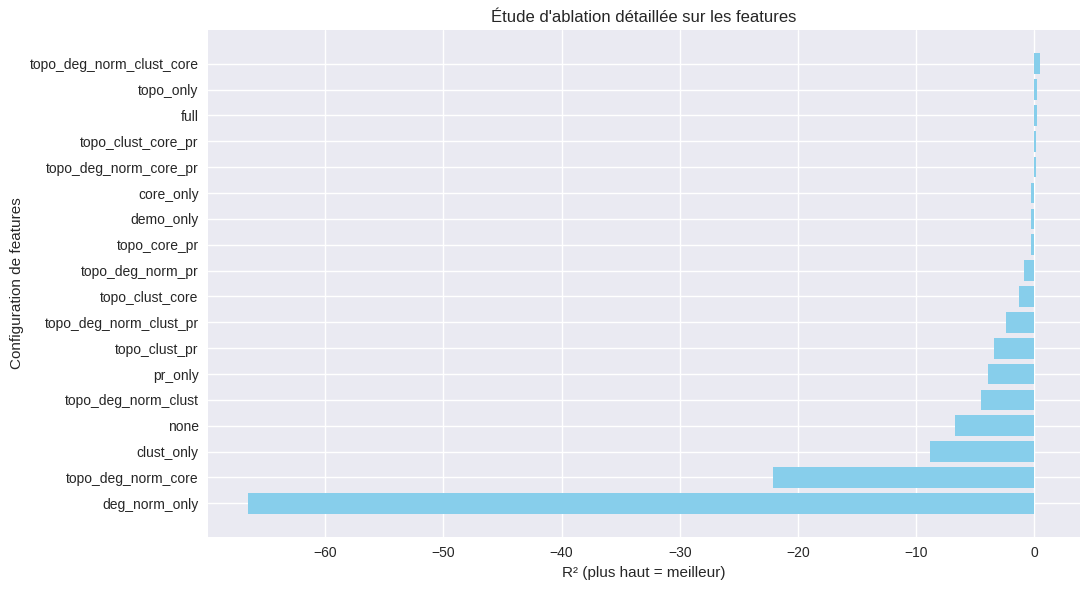

In [43]:
# === Étude d'ablation complète sur les features ===
import itertools
import matplotlib.pyplot as plt

# Vérifier les colonnes disponibles
print("Colonnes disponibles dans X_all :")
print(X_all.columns.tolist())

# Identifier les colonnes topologiques
topo_cols = ["deg_norm", "clust", "core", "pr"]
topo_cols = [c for c in topo_cols if c in X_all.columns]

# Identifier les colonnes démographiques : on suppose qu'elles sont les deux dernières
demo_cols = X_all.columns[-2:].tolist()

print(f"\nColonnes démographiques détectées : {demo_cols}")
print(f"Colonnes topologiques détectées : {topo_cols}")

# Construire les ensembles de features
feature_sets = {
    "demo_only": demo_cols,
    "topo_only": topo_cols,
    "full": demo_cols + topo_cols,
    "none": []
}

# Ajouter des tests individuels pour chaque feature topologique
for f in topo_cols:
    feature_sets[f"{f}_only"] = [f]

# Ajouter des combinaisons partielles de 2 à len(topo_cols)
for r in range(2, len(topo_cols)):
    for combo in itertools.combinations(topo_cols, r):
        name = "_".join(combo)
        feature_sets[f"topo_{name}"] = list(combo)

print(f"\nNombre total de configurations testées : {len(feature_sets)}")

# Lancer l'ablation
abl_results = []

for name, cols in feature_sets.items():
    print(f"\n=== Configuration: {name} ({len(cols)} features) ===")

    if len(cols) == 0:
        data_pyg.x = torch.ones((data_pyg.num_nodes, 1))
    else:
        # S'assurer que les colonnes existent
        missing = [c for c in cols if c not in X_all.columns]
        if missing:
            print(f"⚠️ Colonnes manquantes pour {name}: {missing}")
            continue

        X_sel = X_all[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        data_pyg.x = torch.tensor(X_sel.to_numpy(), dtype=torch.float32)

    # Entraînement court mais cohérent pour la comparaison
    model = train_and_evaluate(GCN, data_pyg, name=f"GCN-{name}", epochs=100)
    model.eval()

    with torch.no_grad():
        preds = model(data_pyg.x, data_pyg.edge_index).view(-1).cpu().numpy()
        y_true = data_pyg.y.view(-1).cpu().numpy()
        mask = data_pyg.test_mask.cpu().numpy()

    # Nettoyage NaN
    mask_valid = ~np.isnan(y_true)
    y_true = y_true[mask_valid]
    preds = preds[mask_valid]
    mask = mask[mask_valid]

    r2 = r2_score(y_true[mask], preds[mask])
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], preds[mask])))
    mae = float(np.mean(np.abs(y_true[mask] - preds[mask])))

    abl_results.append({
        "Configuration": name,
        "Nb_Features": len(cols),
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

# === Résultats ===
abl_df = pd.DataFrame(abl_results).round(4)
abl_df = abl_df.sort_values(by="R²", ascending=False).reset_index(drop=True)

print("\n=== Résultats complets de l'ablation ===")
display(abl_df)

# === Visualisation ===
plt.figure(figsize=(11, 6))
plt.barh(abl_df["Configuration"], abl_df["R²"], color="skyblue")
plt.xlabel("R² (plus haut = meilleur)")
plt.ylabel("Configuration de features")
plt.title("Étude d'ablation détaillée sur les features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 4.2 Visualisation des embeddings appris (t‑SNE / UMAP)

t-SNE sur 5000 points (32 dimensions)


/home/salma/miniconda3/envs/tpdeeprl2025/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


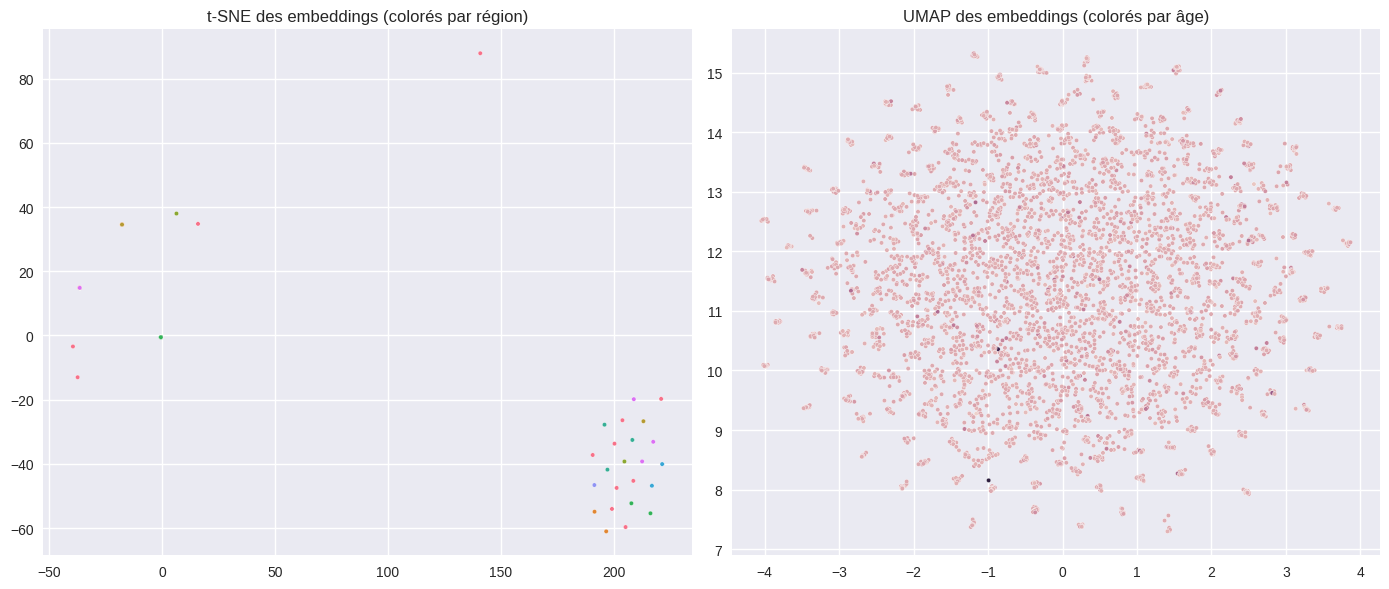

In [44]:
from sklearn.manifold import TSNE
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# Recharger X_all pour cohérence de la viz
data_pyg.x = torch.tensor(X_all.to_numpy(), dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    # On récupère à la fois les prédictions et les embeddings
    pred_tmp, embeddings = best_model(data_pyg.x, data_pyg.edge_index, return_z=True)

# Convertir en numpy et nettoyer les valeurs invalides
embeddings = embeddings.cpu().numpy()
embeddings = np.nan_to_num(embeddings, nan=0.0, posinf=0.0, neginf=0.0)

# Nettoyage de la méta-infos (pour aligner les dimensions)
meta = merged[["region", "age_z"]].reset_index(drop=True)
meta = meta.iloc[:embeddings.shape[0]]

if embeddings.ndim == 1 or embeddings.shape[1] == 1:
    plt.figure(figsize=(8, 6))
    sns.histplot(embeddings.squeeze(), bins=50, kde=True)
    plt.title("Distribution des valeurs de centralité prédites")
    plt.xlabel("Valeur prédite (embedding 1D)")
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()
else:
    max_points = 5000
    if embeddings.shape[0] > max_points:
        idx = np.random.choice(embeddings.shape[0], max_points, replace=False)
        emb_sample = embeddings[idx]
        meta_sample = meta.iloc[idx].reset_index(drop=True)
    else:
        emb_sample = embeddings
        meta_sample = meta

    # Nettoyage supplémentaire de sécurité avant projection
    emb_sample = np.nan_to_num(emb_sample, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"t-SNE sur {emb_sample.shape[0]} points ({emb_sample.shape[1]} dimensions)")
    tsne_emb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb_sample)
    umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(emb_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.scatterplot(
        x=tsne_emb[:, 0], y=tsne_emb[:, 1],
        hue=meta_sample["region"], s=10, ax=axes[0], legend=False
    )
    axes[0].set_title("t-SNE des embeddings (colorés par région)")

    sns.scatterplot(
        x=umap_emb[:, 0], y=umap_emb[:, 1],
        hue=meta_sample["age_z"], s=10, ax=axes[1], legend=False
    )
    axes[1].set_title("UMAP des embeddings (colorés par âge)")

    plt.tight_layout()
    plt.show()


### 4.3 Similarité cosinus + heatmap

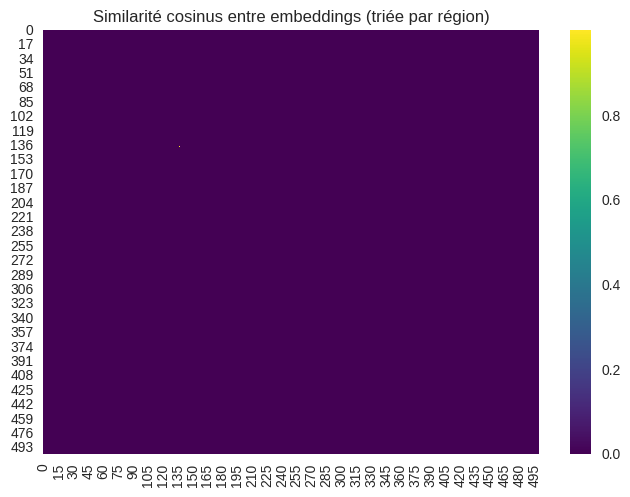

,region,intra,inter
0,banskobystricky kraj,0.000046,0.0
1,bratislavsky kraj,0.000000,0.0
2,nitriansky kraj,0.000000,0.0
3,trnavsky kraj,0.000000,0.0
4,presovsky kraj,0.000000,0.0
5,trenciansky kraj,0.000000,0.0
6,zilinsky kraj,0.000000,0.0
7,kosicky kraj,0.000000,0.0
8,zahranicie,0.000000,0.0
9,ceska republika,0.000000,0.0


In [45]:

from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns, pandas as pd, numpy as np, matplotlib.pyplot as plt

sample_idx = np.random.choice(len(embeddings), size=min(500, len(embeddings)), replace=False)
emb_sample = embeddings[sample_idx]
meta_sample = merged.iloc[sample_idx][["region", "age_z"]].copy()

sim_matrix = cosine_similarity(emb_sample)
sorted_idx = np.argsort(meta_sample["region"].astype(str))
sns.heatmap(sim_matrix[sorted_idx][:, sorted_idx], cmap="viridis", cbar=True)
plt.title("Similarité cosinus entre embeddings (triée par région)")
plt.show()

meta_sample["region"] = meta_sample["region"].astype(str)
group_sim = []
for region in meta_sample["region"].unique():
    idx = meta_sample["region"] == region
    intra = float(sim_matrix[np.ix_(idx, idx)].mean())
    inter = float(sim_matrix[np.ix_(idx, ~idx)].mean())
    group_sim.append({"region": region, "intra": intra, "inter": inter})
pd.DataFrame(group_sim).sort_values("intra", ascending=False)


### 4.4 Prédiction de liens — test d’homophilie (corrigé)

In [48]:
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# === Évaluation du modèle ===
best_model.eval()
with torch.no_grad():
    _, z = best_model(data_pyg.x, data_pyg.edge_index, return_z=True)

# Nettoyage des embeddings : éviter NaN et inf
z = torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)

# === Génération d'arêtes positives et négatives ===
pos_edge_index = data_pyg.edge_index

neg_edge_index = negative_sampling(
    pos_edge_index,
    num_nodes=data_pyg.num_nodes,
    num_neg_samples=pos_edge_index.size(1),
)

# === Fonction de score des liens ===
def link_logits(z, edge_index):
    return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

# === Calcul des scores ===
with torch.no_grad():
    pos_score = torch.sigmoid(link_logits(z, pos_edge_index)).cpu().numpy()
    neg_score = torch.sigmoid(link_logits(z, neg_edge_index)).cpu().numpy()

# Nettoyage des NaN
pos_score = np.nan_to_num(pos_score, nan=0.0, posinf=0.0, neginf=0.0)
neg_score = np.nan_to_num(neg_score, nan=0.0, posinf=0.0, neginf=0.0)

# === Calcul de l'AUC ===
y_true = np.concatenate([np.ones_like(pos_score), np.zeros_like(neg_score)])
y_pred = np.concatenate([pos_score, neg_score])

# Vérification finale
if np.isnan(y_pred).any():
    raise ValueError("NaN détecté dans y_pred même après nettoyage.")

auc = roc_auc_score(y_true, y_pred)
print(f"AUC (homophilie des liens) : {auc:.4f}")


AUC (homophilie des liens) : 0.5000


### 4.5 Détection de communautés : Louvain vs Embeddings

In [50]:
import numpy as np, networkx as nx
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

try:
    import community as community_louvain
except Exception:
    community_louvain = None
    print("⚠️ community-louvain non disponible — installez-le avec `pip install python-louvain`.")

# --- Construire le graphe NetworkX
edges = data_pyg.edge_index.cpu().numpy()
G_tmp = nx.Graph()
G_tmp.add_edges_from(edges.T)

if community_louvain is not None:
    # === Louvain clustering ===
    louvain_partition = community_louvain.best_partition(G_tmp)
    louvain_labels = np.array(list(louvain_partition.values()))

    # === Embeddings du modèle ===
    with torch.no_grad():
        _, embeddings_np = best_model(data_pyg.x, data_pyg.edge_index, return_z=True)
        embeddings_np = embeddings_np.detach().cpu().numpy()

    # Nettoyage des NaN et inf
    embeddings_np = np.nan_to_num(embeddings_np, nan=0.0, posinf=0.0, neginf=0.0)

    # Vérifier qu'on a bien le même nombre de nœuds
    n_louvain = len(louvain_labels)
    n_embed = embeddings_np.shape[0]
    if n_embed != n_louvain:
        min_len = min(n_embed, n_louvain)
        embeddings_np = embeddings_np[:min_len]
        louvain_labels = louvain_labels[:min_len]

    # === KMeans sur les embeddings ===
    k = len(np.unique(louvain_labels))
    print(f"Nombre de communautés Louvain : {k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(embeddings_np)

    # === Calcul du NMI ===
    nmi = normalized_mutual_info_score(louvain_labels, kmeans_labels)
    print(f"NMI entre Louvain et KMeans sur embeddings : {nmi:.3f}")

else:
    print("NMI non calculé (community-louvain absent).")


Nombre de communautés Louvain : 10
NMI entre Louvain et KMeans sur embeddings : 0.003
